In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../../outputs/url", exist_ok=True)


In [3]:
# Load processed dataset
df = pd.read_csv("../../data/processed/urls_processed.csv")

# Divide into subsets by type for easier plotting
benign     = df[df["type"] == "benign"]
defacement = df[df["type"] == "defacement"]
phishing   = df[df["type"] == "phishing"]
malware    = df[df["type"] == "malware"]

# Color mapping for URL types
TYPE_COLORS = {
    "benign"    : "steelblue",
    "defacement": "orange",
    "phishing"  : "tomato",
    "malware"   : "darkred"
}

print(f"Shape: {df.shape}")
print(f"\nDistribution:")
print(df["type"].value_counts())

Shape: (40439, 17)

Distribution:
type
benign        29854
defacement     7455
phishing       2459
malware         671
Name: count, dtype: int64


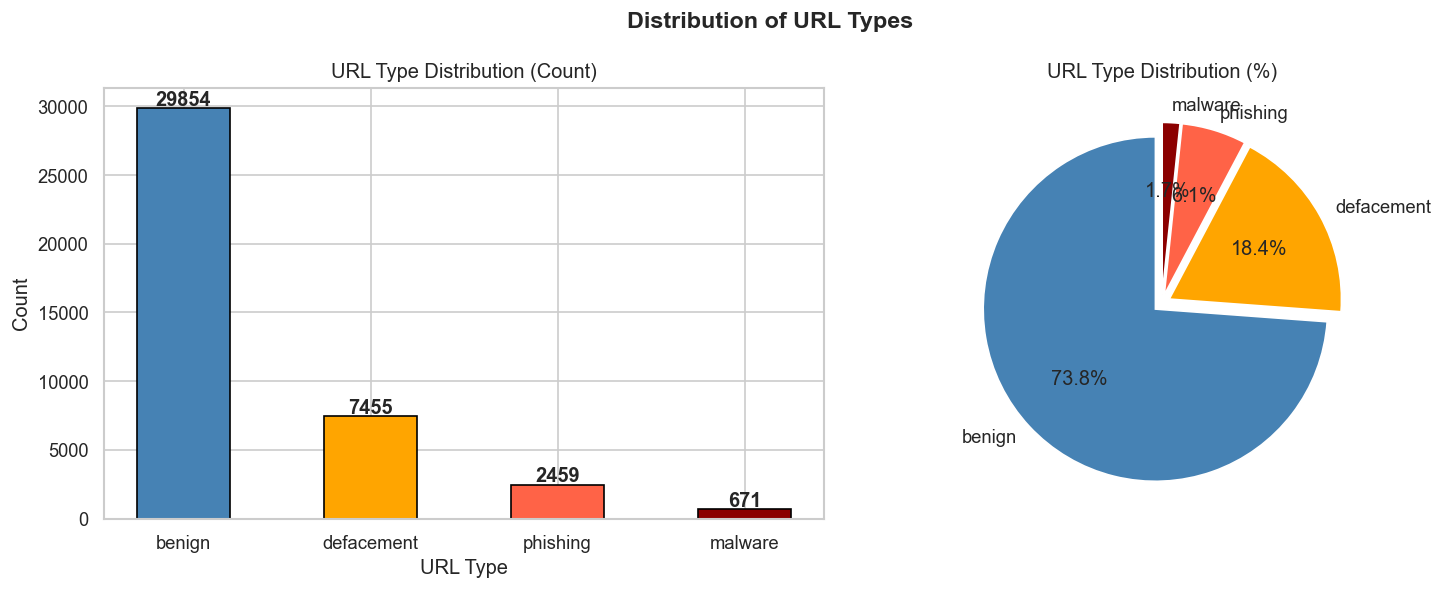

In [4]:
# Label distribution
counts = df["type"].value_counts()
colors = [TYPE_COLORS[t] for t in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart 
bars = axes[0].bar(counts.index, counts.values,
                   color=colors, edgecolor="black", width=0.5)
axes[0].set_title("URL Type Distribution (Count)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("URL Type")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 str(val), ha="center", fontweight="bold")

# Pie chart 
axes[1].pie(counts.values,
            labels=counts.index,
            colors=colors,
            autopct="%1.1f%%",
            startangle=90,
            explode=[0.05] * len(counts))
axes[1].set_title("URL Type Distribution (%)")

plt.suptitle("Distribution of URL Types", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

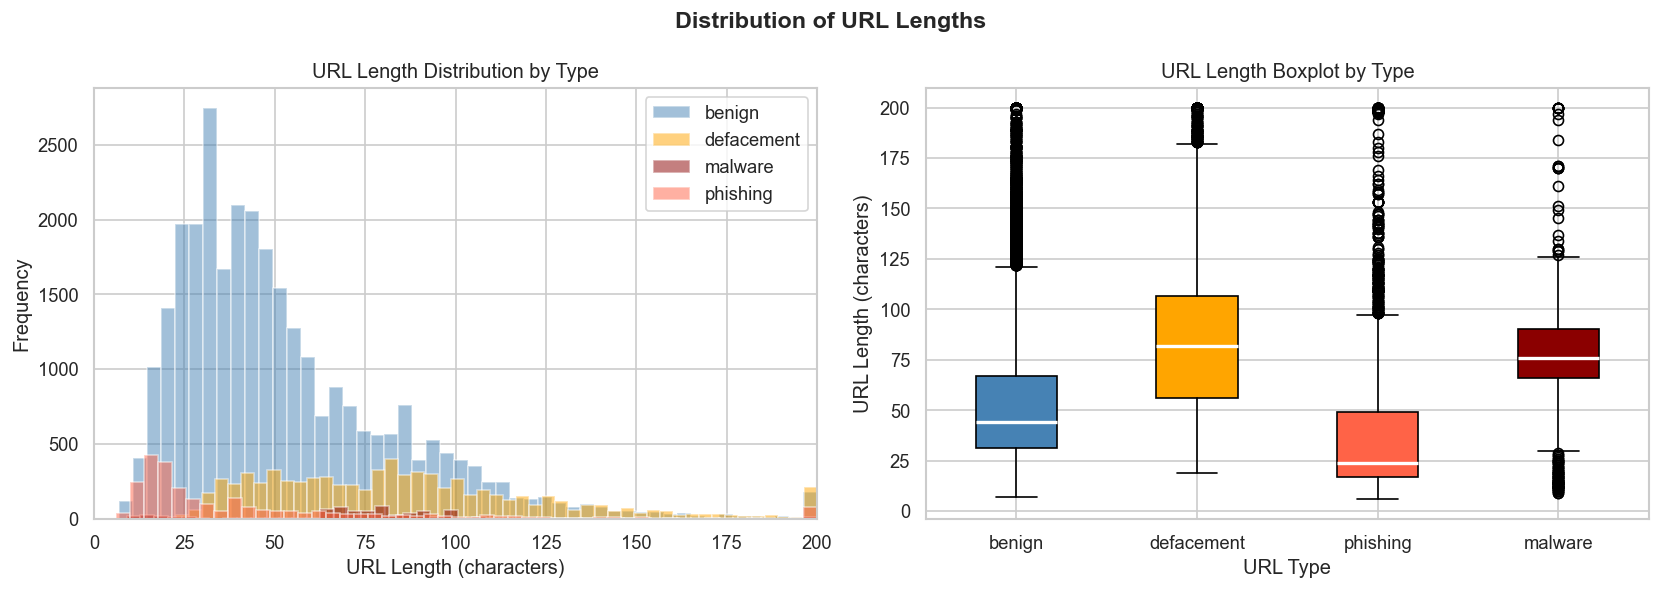

Average URL Length by Type
type
defacement    86.2
malware       75.8
benign        53.1
phishing      41.9
Name: url_length, dtype: float64


In [5]:
# Distribution of URL lengths by type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlapping
for url_type, group in df.groupby("type"):
    axes[0].hist(group["url_length"], bins=50, alpha=0.5,
                 label=url_type, color=TYPE_COLORS[url_type],
                 edgecolor="white")
axes[0].set_title("URL Length Distribution by Type")
axes[0].set_xlabel("URL Length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].set_xlim(0, 200)

# Boxplot
type_order = ["benign", "defacement", "phishing", "malware"]
data_by_type = [df[df["type"] == t]["url_length"] for t in type_order]
bp = axes[1].boxplot(data_by_type, labels=type_order,
                     patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, t in zip(bp["boxes"], type_order):
    patch.set_facecolor(TYPE_COLORS[t])
axes[1].set_title("URL Length Boxplot by Type")
axes[1].set_ylabel("URL Length (characters)")
axes[1].set_xlabel("URL Type")

plt.suptitle("Distribution of URL Lengths", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Average URL Length by Type")
print(df.groupby("type")["url_length"].mean().round(1).sort_values(ascending=False))

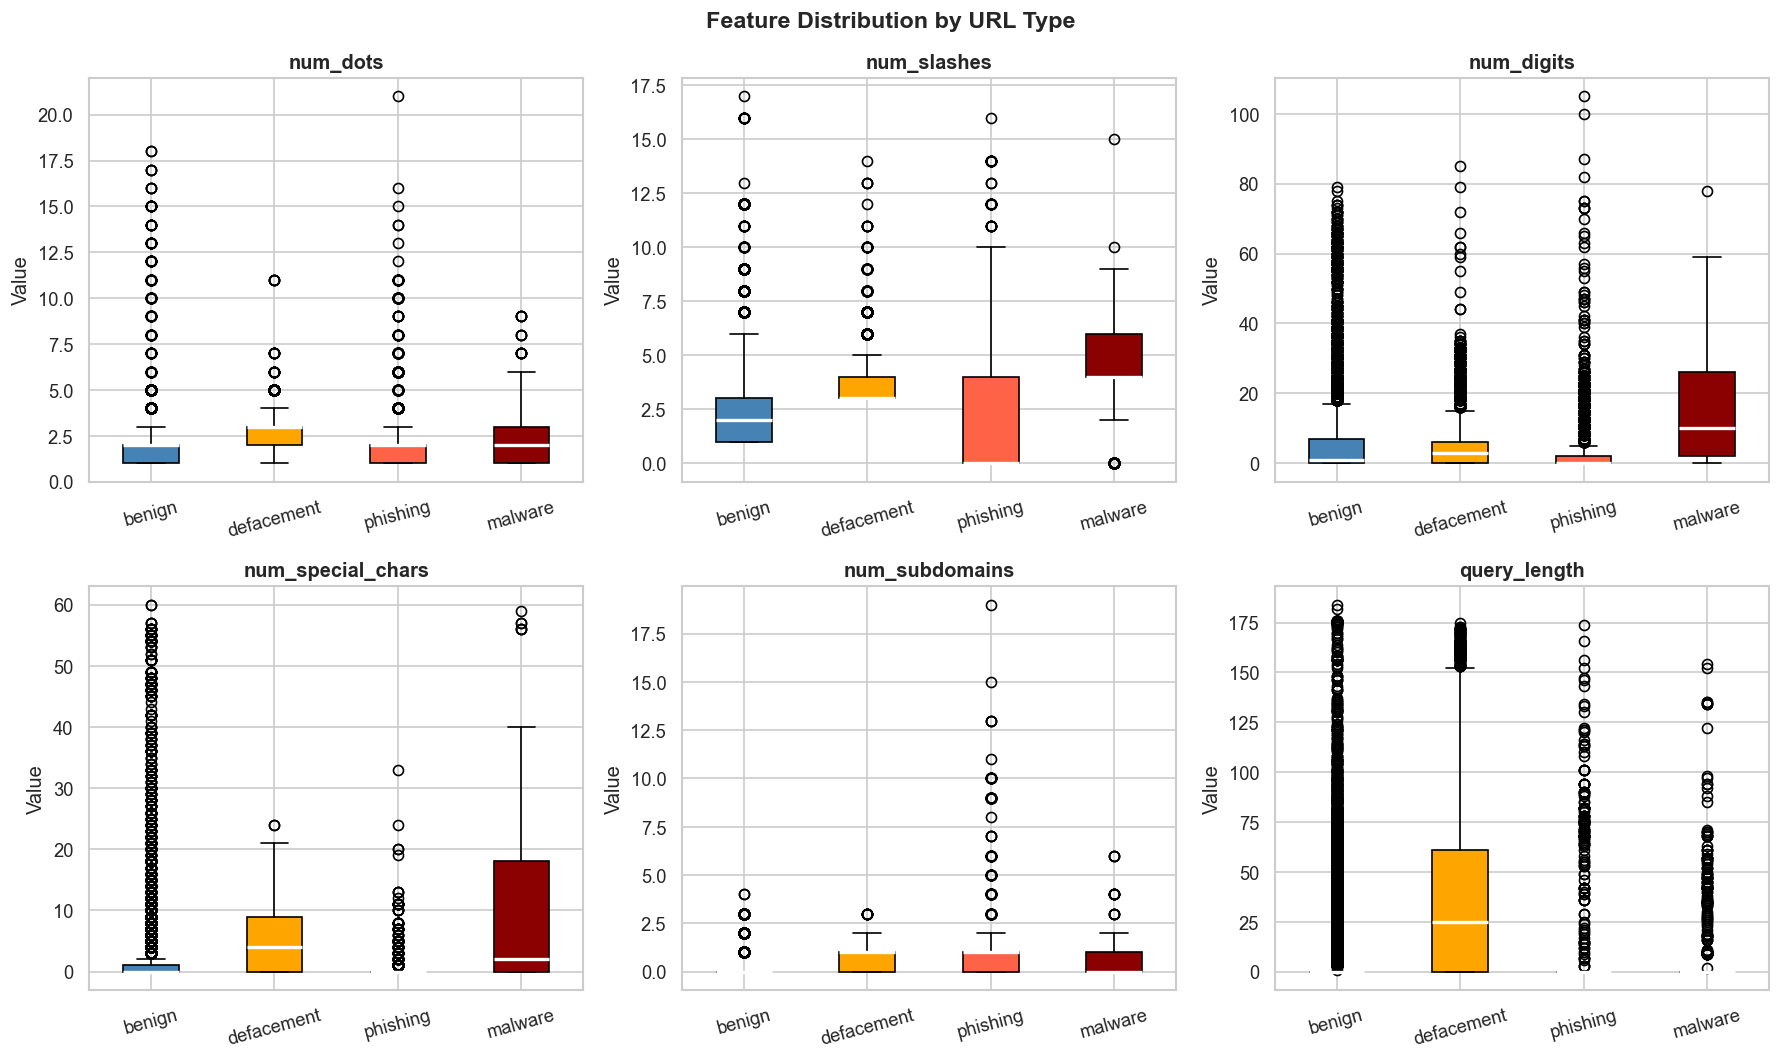

In [6]:
# Feature comparison across URL types
features_to_plot = [
    "num_dots", "num_slashes", "num_digits",
    "num_special_chars", "num_subdomains", "query_length"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    data_by_type = [df[df["type"] == t][feature] for t in type_order]
    bp = axes[i].boxplot(data_by_type, labels=type_order,
                         patch_artist=True,
                         medianprops=dict(color="white", linewidth=2))
    for patch, t in zip(bp["boxes"], type_order):
        patch.set_facecolor(TYPE_COLORS[t])
    axes[i].set_title(f"{feature}", fontweight="bold")
    axes[i].set_ylabel("Value")
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Feature Distribution by URL Type",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

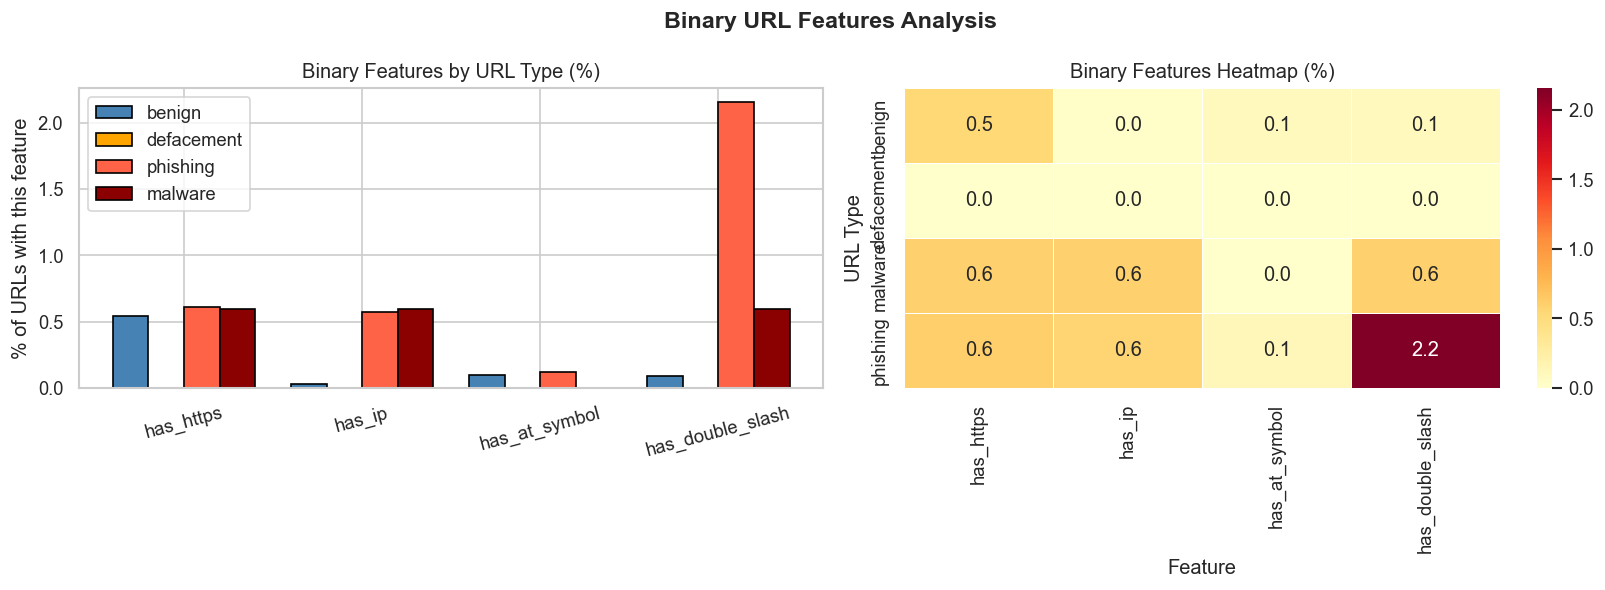

In [7]:
# Binary features — stacked bar chart
binary_features = ["has_https", "has_ip", "has_at_symbol", "has_double_slash"]

# Calculate % of URLs with each binary feature by type
binary_stats = df.groupby("type")[binary_features].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar
x = np.arange(len(binary_features))
width = 0.2
for i, url_type in enumerate(type_order):
    axes[0].bar(x + i * width,
                binary_stats.loc[url_type],
                width, label=url_type,
                color=TYPE_COLORS[url_type],
                edgecolor="black")
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(binary_features, rotation=15)
axes[0].set_ylabel("% of URLs with this feature")
axes[0].set_title("Binary Features by URL Type (%)")
axes[0].legend()

# Heatmap 
sns.heatmap(binary_stats, annot=True, fmt=".1f",
            cmap="YlOrRd", ax=axes[1],
            linewidths=0.5)
axes[1].set_title("Binary Features Heatmap (%)")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("URL Type")

plt.suptitle("Binary URL Features Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

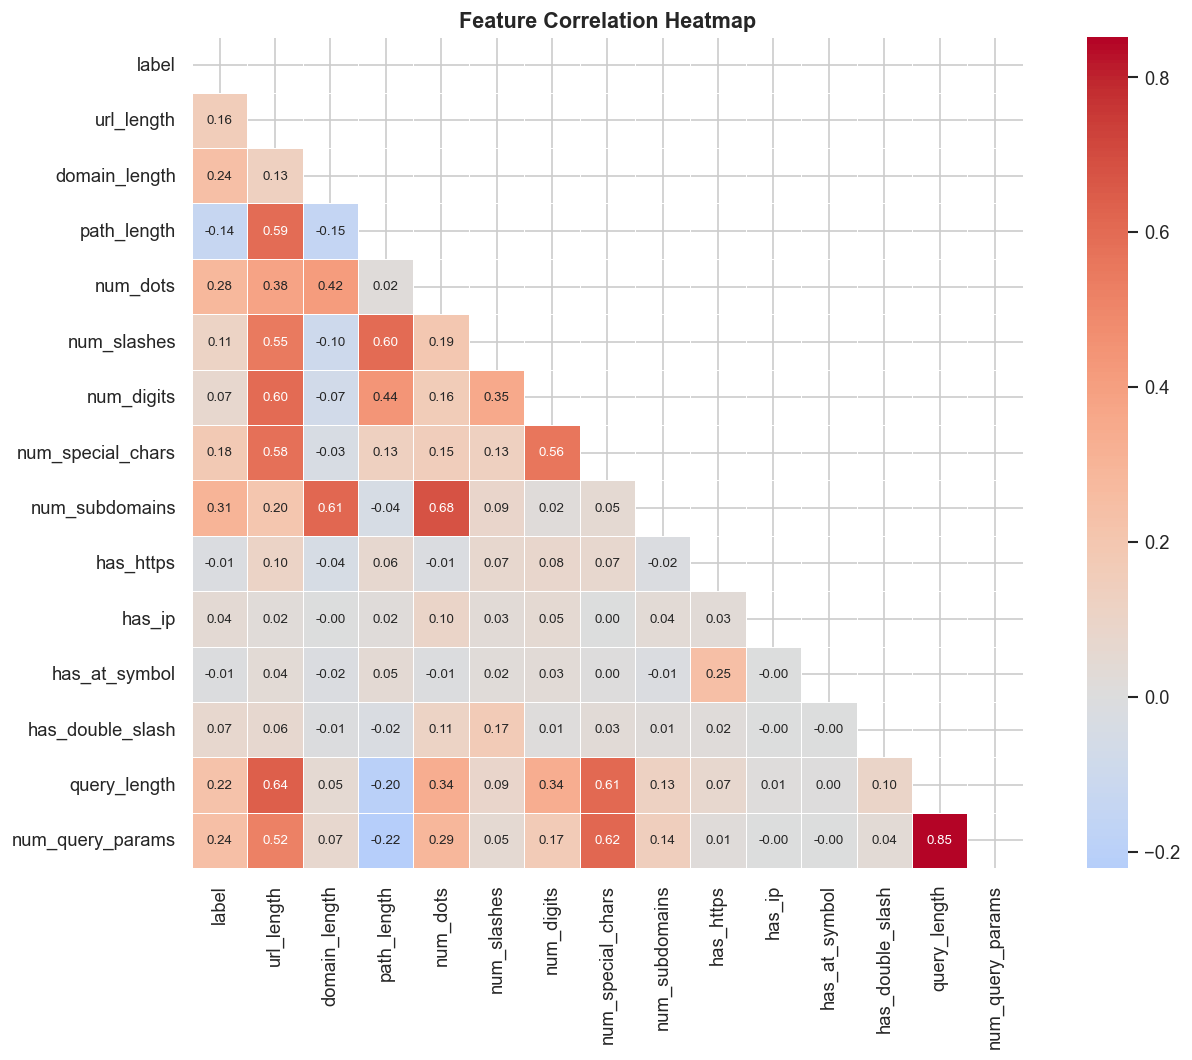

In [8]:
# Correlation heatmap
feature_cols = [c for c in df.columns
                if c not in ["url", "type"]]

corr = df[feature_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.4,
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

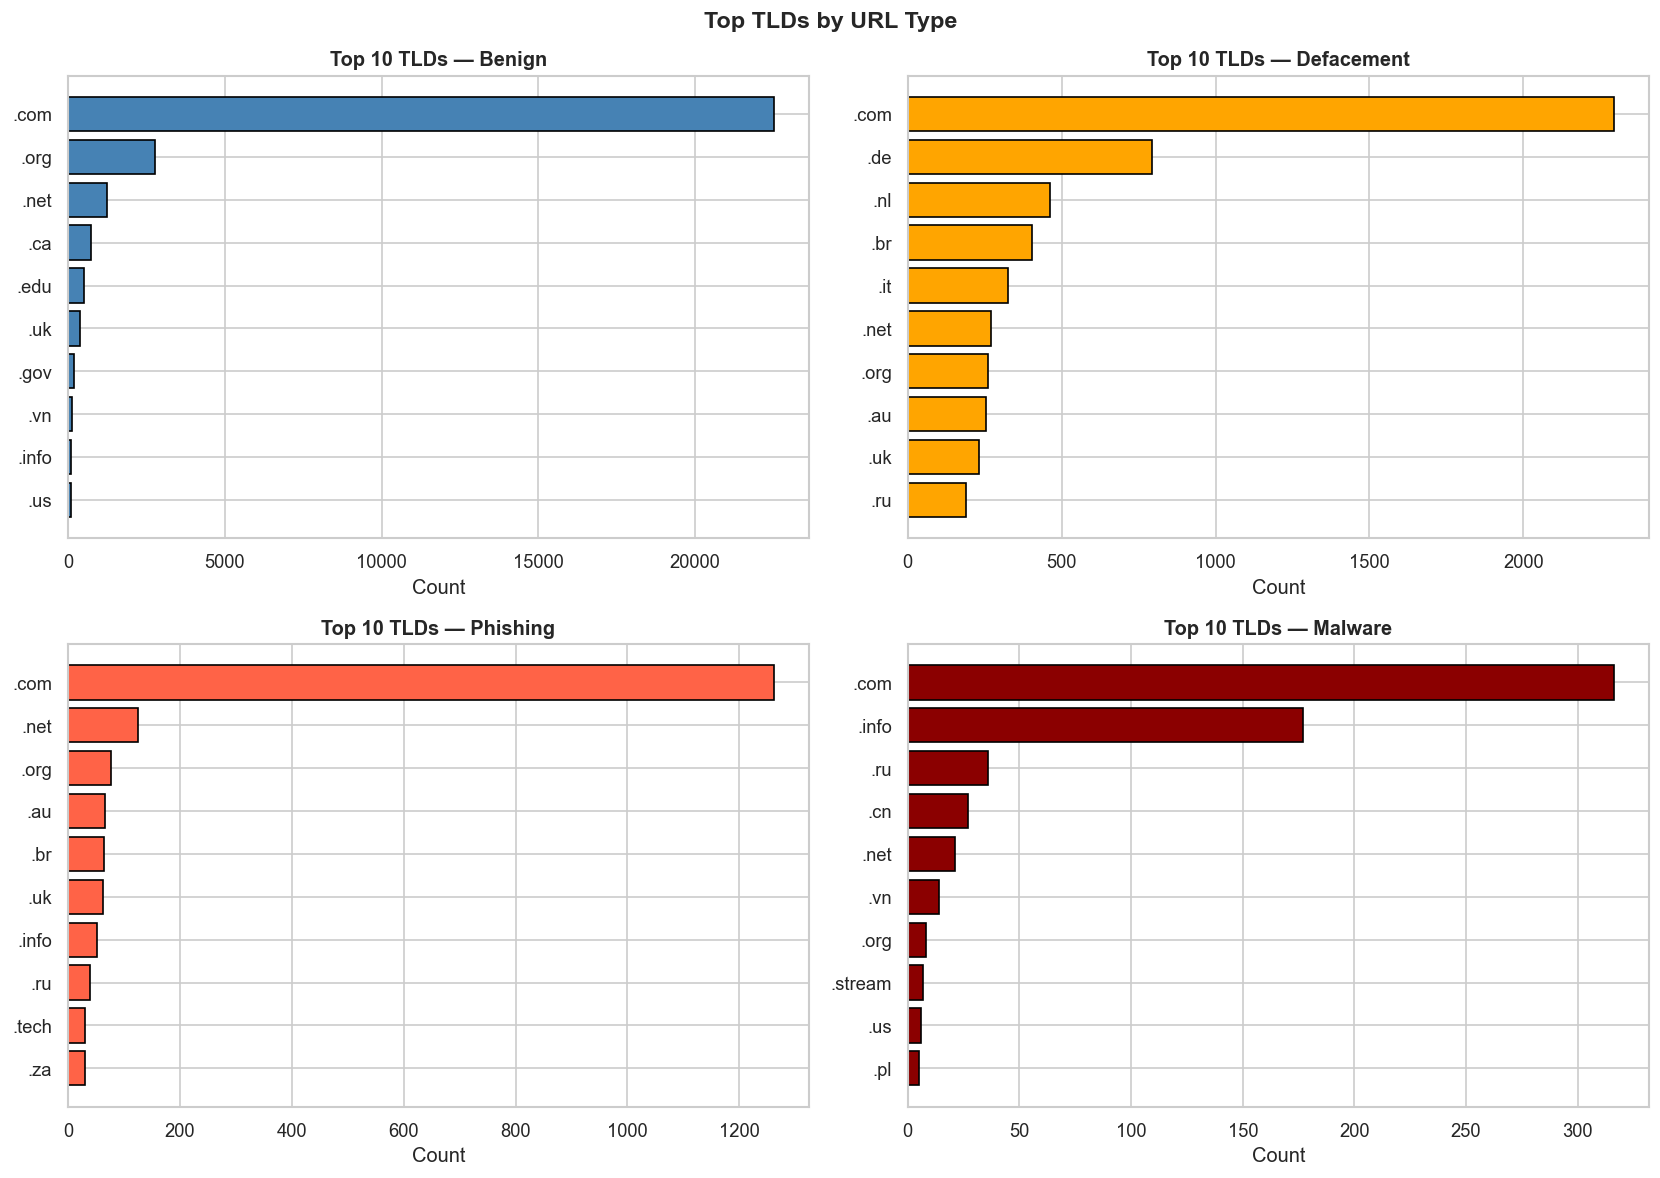

In [9]:
# Top TLD (Top-Level Domain) by URL type
from urllib.parse import urlparse

def extract_tld(url):
    try:
        url = url if url.startswith("http") else "http://" + url
        netloc = urlparse(url).netloc
        parts = netloc.split(".")
        return "." + parts[-1] if len(parts) >= 2 else "unknown"
    except:
        return "unknown"

df["tld"] = df["url"].apply(extract_tld)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, url_type in enumerate(type_order):
    subset = df[df["type"] == url_type]
    top_tlds = subset["tld"].value_counts().head(10)

    axes[i].barh(top_tlds.index[::-1], top_tlds.values[::-1],
                 color=TYPE_COLORS[url_type], edgecolor="black")
    axes[i].set_title(f"Top 10 TLDs — {url_type.capitalize()}",
                      fontweight="bold")
    axes[i].set_xlabel("Count")

plt.suptitle("Top TLDs by URL Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()